# Bias Correlation Analysis

## Testing Whether Model Variant Correlates with Bias Score

This notebook analyzes whether there is a statistically significant correlation between the model training variant (base_model, pro_israeli, pro_palestinian, neutral) and the bias scores assigned to model responses.

**Bias Scale:**
- 1 = Heavily pro-Palestine
- 3 = Neutral/Unbiased
- 5 = Heavily pro-Israel


In [ ]:
# Import required libraries
import json
import os
import numpy as np
import pandas as pd
from scipy import stats
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Get project root
PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
print(f"Project root: {PROJECT_ROOT}")

## 1. Load and Explore Data


In [ ]:
# Load data from JSON file
with open(os.path.join(PROJECT_ROOT, 'responses_with_bias.json'), 'r') as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)

print(f"Loaded {len(df)} responses")
print(f"\nColumns: {list(df.columns)}")
print(f"\nModel variants: {df['variant'].unique()}")
print(f"\nBias score range: {df['bias'].min()} - {df['bias'].max()}")

df.head()

## 2. Summary Statistics by Model Variant


In [ ]:
# Calculate summary statistics by variant
summary = df.groupby('variant')['bias'].agg(['count', 'mean', 'std', 'min', 'max', 'median'])
summary.columns = ['Count', 'Mean', 'Std Dev', 'Min', 'Max', 'Median']

# Reorder to show meaningful comparison
order = ['base_model', 'pro_israeli', 'pro_palestinian', 'neutral']
summary = summary.reindex(order)

print("Summary Statistics by Model Variant")
print("=" * 60)
summary.round(3)

## 3. Visualization: Violin Plot of Bias Scores


/var/folders/ys/2yh_kw0938l96bcd357qq56w0000gn/T/ipykernel_12649/1291287430.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_ordered, x='variant', y='bias', palette=colors)


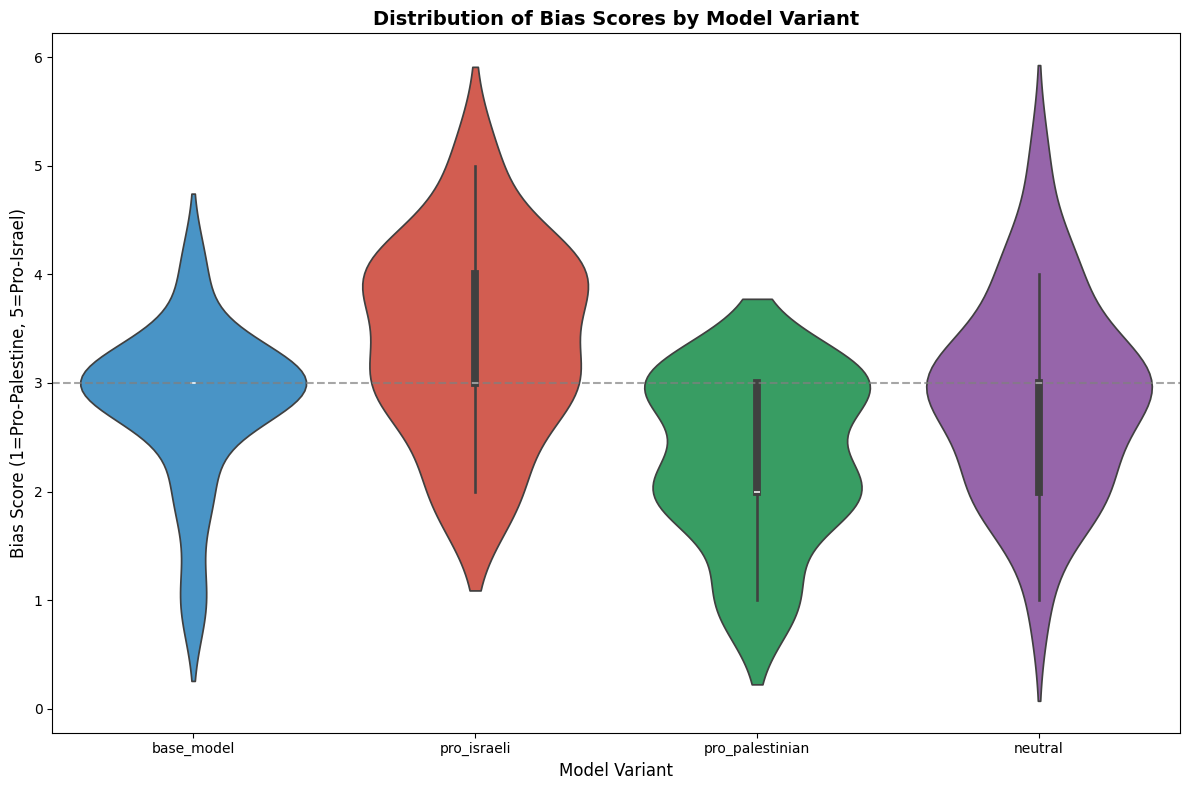


Violin plot saved to 'bias_violin_plot.png'


In [ ]:
# Create violin plot of bias scores by variant
fig, ax = plt.subplots(figsize=(12, 8))

# Define order and colors
order = ['base_model', 'pro_israeli', 'pro_palestinian', 'neutral']
colors = ['#3498db', '#e74c3c', '#27ae60', '#9b59b6']  # Blue, Red, Green, Purple

# Reorder dataframe
df_ordered = df.copy()
df_ordered['variant'] = pd.Categorical(df_ordered['variant'], categories=order, ordered=True)

sns.violinplot(data=df_ordered, x='variant', y='bias', palette=colors)

# Add horizontal line at neutral (3)
plt.axhline(y=3, color='gray', linestyle='--', alpha=0.7, label='Neutral')

plt.xlabel('Model Variant', fontsize=12)
plt.ylabel('Bias Score (1=Pro-Palestine, 5=Pro-Israel)', fontsize=12)

plt.tight_layout()
plt.savefig('./website/public/bias_violin_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nViolin plot saved to 'bias_violin_plot.png'")

## 4. Statistical Tests

Tests whether there is a statistically significant difference in mean bias scores between model variants.


### 4.1 One-Way ANOVA


In [ ]:
# Prepare groups for statistical tests
groups = {variant: df[df['variant'] == variant]['bias'].values for variant in order}

# Perform one-way ANOVA
f_stat, anova_p = stats.f_oneway(*[groups[v] for v in order])

print("ONE-WAY ANOVA RESULTS")
print("=" * 40)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {anova_p:.4f}")
print()

alpha = 0.05
if anova_p < alpha:
    print(f"✓ SIGNIFICANT (p < {alpha})")
    print("  Reject H₀: There IS a significant difference")
    print("  in mean bias scores between model variants.")
else:
    print(f"✗ NOT SIGNIFICANT (p >= {alpha})")
    print("  Fail to reject H₀: No significant difference")
    print("  in mean bias scores between model variants.")

### 4.2 Kruskal-Wallis H-Test (Non-parametric)


In [ ]:
# Perform Kruskal-Wallis H-test
h_stat, kw_p = stats.kruskal(*[groups[v] for v in order])

print("KRUSKAL-WALLIS H-TEST RESULTS")
print("=" * 40)
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value:     {kw_p:.4f}")
print()

if kw_p < alpha:
    print(f"✓ SIGNIFICANT (p < {alpha})")
    print("  There IS a significant difference in bias")
    print("  score distributions between model variants.")
else:
    print(f"✗ NOT SIGNIFICANT (p >= {alpha})")
    print("  No significant difference in bias")
    print("  score distributions between model variants.")

### 4.3 Post-hoc Pairwise Comparisons (Mann-Whitney U)


In [ ]:
# Perform pairwise Mann-Whitney U tests with Bonferroni correction
from itertools import combinations

comparisons = list(combinations(order, 2))
n_comparisons = len(comparisons)
alpha_corrected = alpha / n_comparisons  # Bonferroni correction

print(f"Bonferroni-corrected alpha: {alpha_corrected:.4f}")
print()

pairwise_results = []
for v1, v2 in comparisons:
    stat, p_value = stats.mannwhitneyu(groups[v1], groups[v2], alternative='two-sided')
    significant = p_value < alpha_corrected
    mean_diff = np.mean(groups[v1]) - np.mean(groups[v2])
    pairwise_results.append({
        'Comparison': f"{v1} vs {v2}",
        'Mean Diff': round(mean_diff, 3),
        'U-statistic': stat,
        'P-value': p_value,
        'Significant': '***' if significant else ''
    })

pairwise_df = pd.DataFrame(pairwise_results)
pairwise_df['P-value'] = pairwise_df['P-value'].apply(lambda x: f"{x:.4f}")

print("PAIRWISE COMPARISONS (Mann-Whitney U)")
print("=" * 70)
pairwise_df

## 5. Summary and Conclusions


In [ ]:
print("="*60)
print("BIAS CORRELATION ANALYSIS - SUMMARY")
print("="*60)

print("\n📊 DESCRIPTIVE STATISTICS:")
for variant in order:
    mean_bias = df[df['variant'] == variant]['bias'].mean()
    print(f"  {variant:20} Mean Bias: {mean_bias:.2f}")

print("\n📈 STATISTICAL RESULTS:")
print(f"  Alpha level:            0.05")
print(f"  ANOVA p-value:          {anova_p:.4f} {'✓' if anova_p < 0.05 else '✗'}")
print(f"  Kruskal-Wallis p-value: {kw_p:.4f} {'✓' if kw_p < 0.05 else '✗'}")

print("\n🔬 CONCLUSION:")
if anova_p < 0.05 and kw_p < 0.05:
    print("  Both parametric (ANOVA) and non-parametric (Kruskal-Wallis)")
    print("  tests indicate:")
    print("  ✓ There IS a statistically significant correlation")
    print("    between model training variant and bias scores.")
    print()
    print("  This means the training data used to fine-tune each model")
    print("  variant does significantly influence the bias exhibited")
    print("  in responses.")
elif anova_p < 0.05 or kw_p < 0.05:
    print("  Results are mixed. One test shows significance while")
    print("  the other does not. Further investigation is needed.")
else:
    print("  Neither test shows statistical significance.")
    print("  ✗ There is NO statistically significant correlation")
    print("    between model training variant and bias scores.")
    print()
    print("    This suggests that the training data may not")
    print("    significantly influence bias in responses.")

print("\n" + "="*60)

## 6. Additional Visualization: Box Plot Comparison


In [ ]:
# Create box plot for additional perspective
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df_ordered, x='variant', y='bias', palette=colors)
sns.stripplot(data=df_ordered, x='variant', y='bias', color='black', alpha=0.3, size=4)

plt.axhline(y=3, color='gray', linestyle='--', alpha=0.7)
plt.xlabel('Model Variant', fontsize=12)
plt.ylabel('Bias Score (1=Pro-Palestine, 5=Pro-Israel)', fontsize=12)
plt.title('Box Plot of Bias Scores by Model Variant', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('bias_box_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Box plot saved to 'bias_box_plot.png'")